<a href="https://colab.research.google.com/github/Ruthwikau18/CodSoft_05/blob/main/CodSoft_Task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CODSOFT TASK-5 WEB DATA EXTRACTION & ANALYSIS**

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
url = "https://books.toscrape.com/"
response = requests.get(url)

print("Status Code:", response.status_code)

soup = BeautifulSoup(response.text, "html.parser")

Status Code: 200


Scrape multiple pages

In [ ]:
books = []

for page in range(1, 6):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    for book in soup.select("article.product_pod"):
        title = book.h3.a["title"]
        price = book.select_one(".price_color").text.strip()
        rating = book.select_one("p.star-rating")["class"][1]
        availability = book.select_one(".availability").get_text(strip=True)

        books.append({
            "Product_Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability
        })

    time.sleep(1)

print("Total records:", len(books))

Total records: 100


In [ ]:
df = pd.DataFrame(books)
df.head()

,Product_Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

(100, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product_Title  100 non-null    object
 1   Price          100 non-null    object
 2   Rating         100 non-null    object
 3   Availability   100 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB
None
Product_Title    0
Price            0
Rating           0
Availability     0
dtype: int64
0


In [ ]:
# Clean Price
df["Price"] = df["Price"].astype(str)
df["Price"] = df["Price"].str.extract(r"(\d+\.?\d*)")[0]
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Clean Rating
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

# Clean Availability
df["Availability"] = (
    df["Availability"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("Cleaning completed!")
print(df.head())
print(df.info())

Cleaning completed!
                           Product_Title  Price  Rating Availability
0                   A Light in the Attic  51.77       3     In stock
1                     Tipping the Velvet  53.74       1     In stock
2                             Soumission  50.10       1     In stock
3                          Sharp Objects  47.82       4     In stock
4  Sapiens: A Brief History of Humankind  54.23       5     In stock
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_Title  100 non-null    object 
 1   Price          100 non-null    float64
 2   Rating         100 non-null    int64  
 3   Availability   100 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.3+ KB
None


In [ ]:
print("Average Price:", round(df["Price"].mean(), 2))
print("Minimum Price:", round(df["Price"].min(), 2))
print("Maximum Price:", round(df["Price"].max(), 2))

Average Price: 34.56
Minimum Price: 10.16
Maximum Price: 58.11


In [ ]:
print(df["Rating"].value_counts().sort_index())

Rating
1    22
2    19
3    22
4    18
5    19
Name: count, dtype: int64


In [ ]:
df.nlargest(10, "Price")[["Product_Title", "Price", "Rating"]]

,Product_Title,Price,Rating
68,The Death of Humanity: and the Case for Life,58.11,4
40,Slow States of Collapse: Poems,57.31,3
15,Our Band Could Be Your Life: Scenes from the A...,57.25,3
58,The Past Never Ends,56.50,4
57,The Pioneer Woman Cooks: Dinnertime: Comfort C...,56.41,1
91,Masks and Shadows,56.40,2
56,The Secret of Dreadwillow Carse,56.13,1
67,The Electric Pencil: Drawings from Inside Stat...,56.06,1
25,Birdsong: A Story in Pictures,54.64,3
4,Sapiens: A Brief History of Humankind,54.23,5


In [ ]:
df.nsmallest(10, "Price")[["Product_Title", "Price", "Rating"]]

,Product_Title,Price,Rating
84,Patience,10.16,3
20,In Her Wake,12.84,1
81,Princess Between Worlds (Wide-Awake Princess #5),13.34,5
80,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",13.61,5
10,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,2
92,Mama Tried: Traditional Italian Cooking for th...,14.02,4
88,On a Midnight Clear,14.07,3
47,Untitled Collection: Sabbath Poems 2014,14.27,4
89,Obsidian (Lux #1),14.86,2
85,"Outcast, Vol. 1: A Darkness Surrounds Him (Out...",15.44,4


**Visualisation**

1.Price distribution

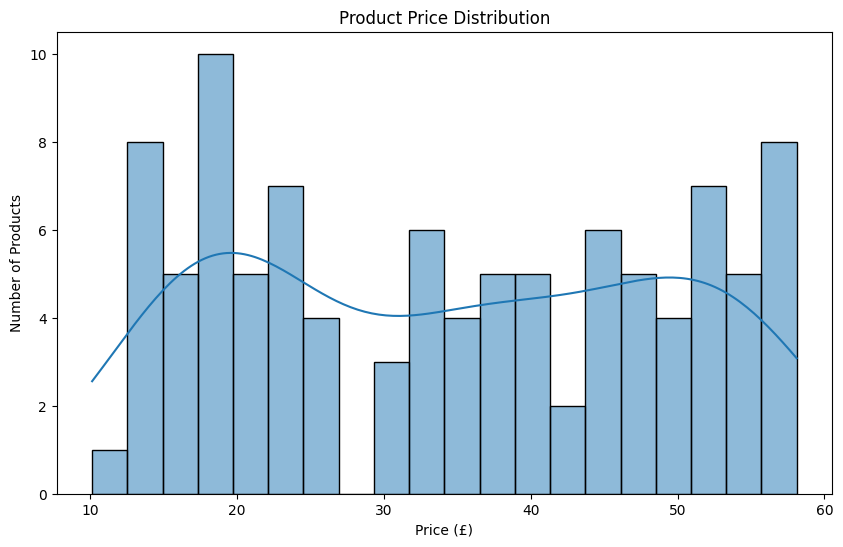

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Price"], bins=20, kde=True)

plt.title("Product Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Products")
plt.show()

2.Rating distribution

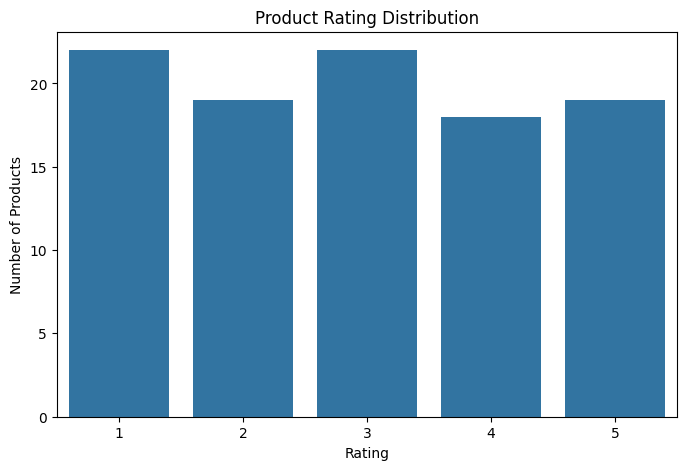

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x="Rating", data=df)

plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.show()

3.Average price by rating

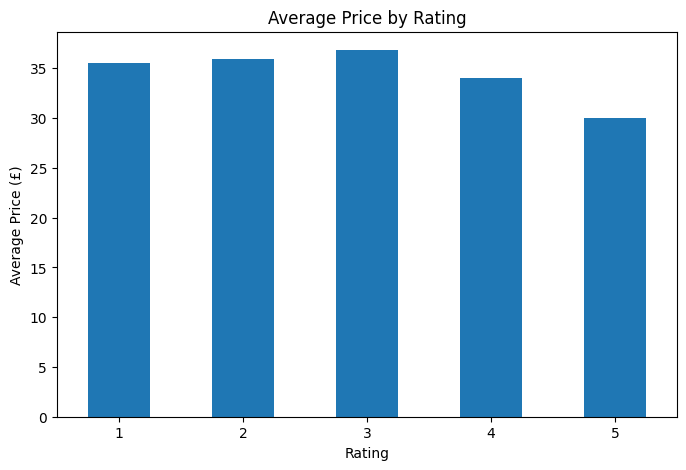

In [ ]:
avg_price_rating = df.groupby("Rating")["Price"].mean()

plt.figure(figsize=(8, 5))

avg_price_rating.plot(kind="bar")

plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=0)
plt.show()

4.Top 10 expensive products

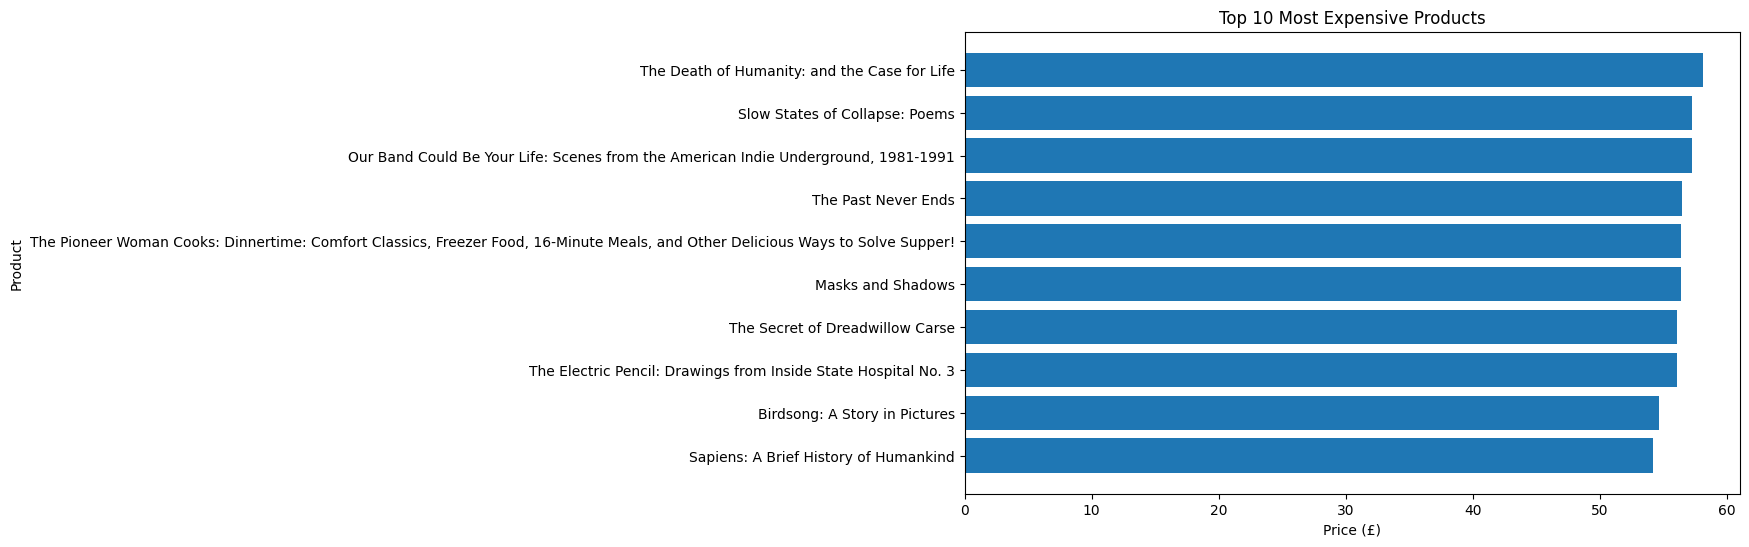

In [ ]:
top_expensive = df.nlargest(10, "Price")

plt.figure(figsize=(10, 6))

plt.barh(
    top_expensive["Product_Title"],
    top_expensive["Price"]
)

plt.title("Top 10 Most Expensive Products")
plt.xlabel("Price (£)")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

5.Rating vs price

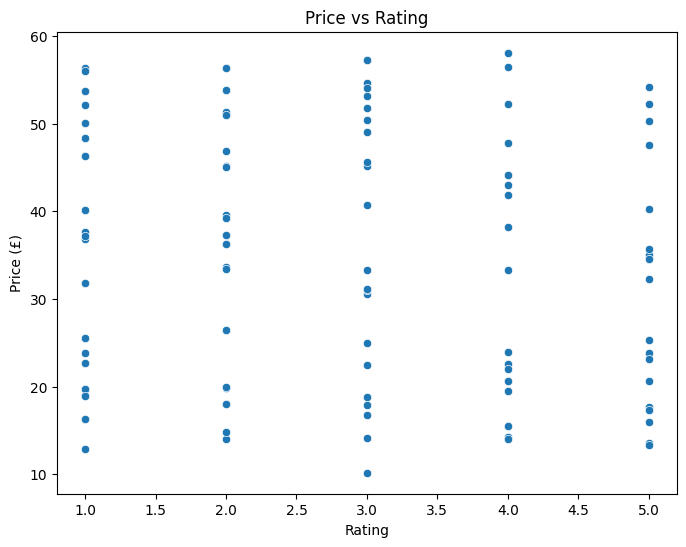

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Rating",
    y="Price"
)

plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.show()

6.Availability analysis

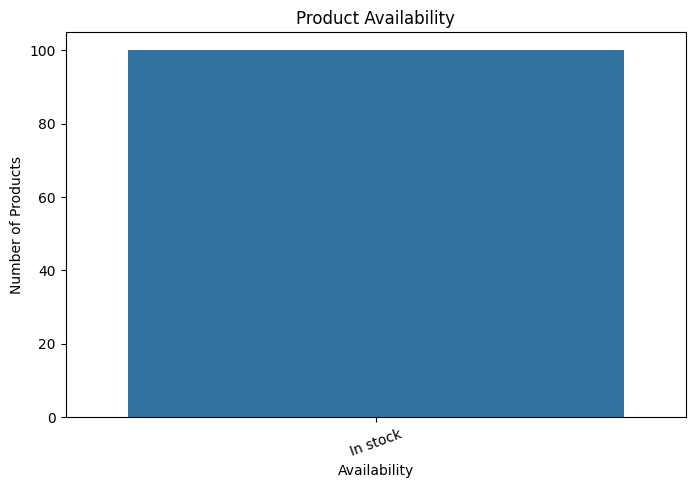

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Availability"
)

plt.title("Product Availability")
plt.xlabel("Availability")
plt.ylabel("Number of Products")
plt.xticks(rotation=20)
plt.show()

7.Price boxplot

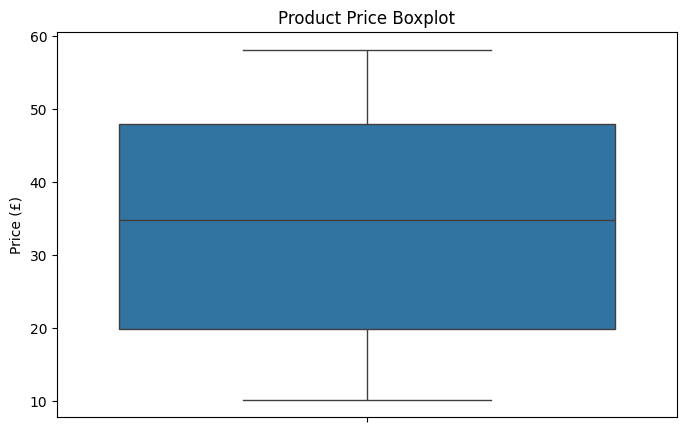

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["Price"])

plt.title("Product Price Boxplot")
plt.ylabel("Price (£)")
plt.show()

8.Correlation analysis

           Price    Rating
Price   1.000000 -0.121741
Rating -0.121741  1.000000


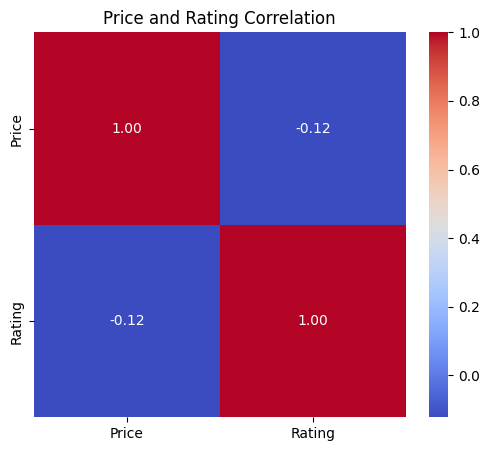

In [ ]:
correlation = df[["Price", "Rating"]].corr()

print(correlation)

plt.figure(figsize=(6, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Price and Rating Correlation")
plt.show()

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

In [ ]:
books = []

for page in range(1, 6):

    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)

    print("Page", page, "Status:", response.status_code)

    soup = BeautifulSoup(response.text, "html.parser")

    for book in soup.select("article.product_pod"):

        title = book.h3.a["title"]

        price = book.select_one(".price_color").get_text(strip=True)

        rating = book.select_one("p.star-rating")["class"][1]

        availability = book.select_one(
            ".availability"
        ).get_text(" ", strip=True)

        books.append({
            "Product_Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability
        })

    time.sleep(1)

print("Total books collected:", len(books))

Page 1 Status: 200
Page 2 Status: 200
Page 3 Status: 200
Page 4 Status: 200
Page 5 Status: 200
Total books collected: 100


In [ ]:
df = pd.DataFrame(books)

print(df.head())

                           Product_Title    Price Rating Availability
0                   A Light in the Attic  Â£51.77  Three     In stock
1                     Tipping the Velvet  Â£53.74    One     In stock
2                             Soumission  Â£50.10    One     In stock
3                          Sharp Objects  Â£47.82   Four     In stock
4  Sapiens: A Brief History of Humankind  Â£54.23   Five     In stock


In [ ]:
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

In [ ]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

In [ ]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(df.shape)
print(df.head())
print(df.info())

(100, 4)
                           Product_Title  Price  Rating Availability
0                   A Light in the Attic  51.77       3     In stock
1                     Tipping the Velvet  53.74       1     In stock
2                             Soumission  50.10       1     In stock
3                          Sharp Objects  47.82       4     In stock
4  Sapiens: A Brief History of Humankind  54.23       5     In stock
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_Title  100 non-null    object 
 1   Price          100 non-null    float64
 2   Rating         100 non-null    int64  
 3   Availability   100 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.3+ KB
None


In [ ]:
df.to_csv(
    "codsoft_task5_scraped_data.csv",
    index=False
)

print("CSV file created successfully!")

CSV file created successfully!


In [ ]:
df.to_excel(
    "codsoft_task5_scraped_data.xlsx",
    index=False
)

print("Excel file created successfully!")

Excel file created successfully!


In [ ]:
from google.colab import files

files.download("codsoft_task5_scraped_data.csv")
files.download("codsoft_task5_scraped_data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>